# AA-UTE 2026
## Modelos de regresión para series temporales

Adaptado del contenido del capítulo 7 del libro *Forecasting: Principles and Practice, the Pythonic Way* [1].



### Contenido

| Paso | Acción |
|------|--------|
| 1 | Cargar bibliotecas |
| 2 | Cargar datos |
| 3 | Modelo lineal simple |
| 4 | Regresión múltiple |
| 5 | Evaluación del ajuste y residuos |
| 6 | Predictores útiles: tendencia, dummies y Fourier |
| 7 | Selección de predictores |
| 8 | Pronóstico con regresión |

[1] Hyndman, R.J., Athanasopoulos, G., Garza, A., Challu, C., Mergenthaler, M., & Olivares, K.G. (2026). *Forecasting: Principles and Practice, the Pythonic Way*. OTexts: Melbourne, Australia. Available at: OTexts.com/fpppy. Accessed on 9 July 2026.

---

## PASO 1: Importar bibliotecas

Usaremos herramientas estándar para trabajar con datos y modelos de regresión:

- `pandas` y `numpy` para manipulación numérica.
- `matplotlib` para visualización.
- `statsmodels` para ajustar regresiones y obtener diagnósticos.
- `sklearn` solo para algunas utilidades de referencia.

La idea no es usar una caja negra, sino ver claramente qué está haciendo cada modelo.

In [1]:
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from scipy import stats
from sklearn.linear_model import LinearRegression
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
np.random.seed(42)



In [3]:
def fit_linear_regression(X, y):
    model = LinearRegression()
    model.fit(X, y)
    fitted = pd.Series(model.predict(X), index=y.index)
    residuals = pd.Series(y - fitted, index=y.index)
    return model, fitted, residuals


def regression_summary(model, X, y, feature_names):
    if isinstance(X, pd.DataFrame):
        X_values = X.to_numpy(dtype=float)
        X_predict = X
    else:
        X_values = np.asarray(X, dtype=float)
        X_predict = pd.DataFrame(X_values, columns=feature_names)
    y_values = np.asarray(y, dtype=float)
    n, p = X_values.shape
    X_design = np.column_stack([np.ones(n), X_values])
    coef = np.r_[model.intercept_, model.coef_]
    fitted = model.predict(X_predict)
    resid = y_values - fitted
    dof = n - p - 1
    rss = np.sum(resid ** 2)
    mse = rss / dof
    var_beta = mse * np.linalg.inv(X_design.T @ X_design).diagonal()
    se_beta = np.sqrt(var_beta)
    t_stats = coef / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))
    stars_lookup = np.array(['***', '**', '*', '.', ''])
    stars = np.select(
        [p_values < 0.001, p_values < 0.01, p_values < 0.05, p_values < 0.1],
        stars_lookup[:4],
        default=''
    )
    index = ['(Intercept)'] + feature_names
    resid_summary = pd.DataFrame(
        {label: [value] for label, value in zip(['Min', '1Q', 'Median', '3Q', 'Max'], np.percentile(resid, [0, 25, 50, 75, 100]))},
        index=['']
    )
    coef_summary = pd.DataFrame(
        {
            'Estimate': coef,
            'Std. Error': se_beta,
            't value': t_stats,
            'Pr(>|t|)': p_values,
            '': stars,
        },
        index=index,
    )
    r_squared = model.score(X_predict, y_values)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / dof
    f_stat = (r_squared / p) / ((1 - r_squared) / dof) if p > 0 else np.nan
    f_pval = 1 - stats.f.cdf(f_stat, p, dof) if p > 0 else np.nan
    print(f'Residuals:\n{resid_summary}\n\nCoefficients:\n{coef_summary}')
    print('---')
    print("Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1\n")
    print(
        f'Residual standard error: {np.sqrt(mse):.3f}',
        f'on {dof} degrees of freedom',
        f'\nMultiple R-squared: {r_squared:.3f},   ',
        f'Adjusted R-squared: {adj_r_squared:.3f}',
        f'\nF-statistic: {f_stat:.1f} on {p}',
        f'and {dof} DF, p-value: {f_pval:.3g}'
    )


def plot_regression_diagnostics(y, fitted, title='Diagnóstico de residuos'):
    resid = y - fitted
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()
    axes[0].plot(np.arange(len(resid)), resid, color='tab:blue')
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title('Residuos en el tiempo')
    axes[1].hist(resid, bins=20, color='tab:orange', edgecolor='black')
    axes[1].set_title('Histograma de residuos')
    axes[2].scatter(fitted, resid, color='black', alpha=0.7)
    axes[2].axhline(0, color='red', linestyle='--')
    axes[2].set_title('Residuos vs valores ajustados')
    axes[2].set_xlabel('Fitted')
    axes[2].set_ylabel('Residual')
    plot_acf(resid, lags=20, zero=False, ax=axes[3])
    axes[3].set_title('ACF de residuos')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def prepare_fourier(df, period, order, time_col='trend'):
    result = df.copy()
    t = result[time_col].to_numpy()
    for k in range(1, order + 1):
        result[f'sin{k}'] = np.sin(2 * np.pi * k * t / period)
        result[f'cos{k}'] = np.cos(2 * np.pi * k * t / period)
    return result

---

## PASO 2: Cargar datos del capítulo

El capítulo 7 usa varios conjuntos de datos públicos del libro.

En este notebook vamos a reutilizar los más representativos:

- `US_change.csv`: cambios trimestrales en consumo e ingreso de EE.UU.
- `aus_production_formatted.csv`: producción trimestral australiana, útil para tendencia y estacionalidad.
- `boston_marathon.csv`: tiempos ganadores del maratón de Boston, útil para regresión no lineal.
- `aus_airpassengers.csv` y `guinea_rice.csv`: ejemplo clásico de regresión espuria.

In [5]:
data_dir = Path('datos/fpppy')

#files = ['global_economy.csv', 'aus_production_formatted.csv', 'gafa_stock.csv']

us_change = pd.read_csv(data_dir / 'US_change.csv', parse_dates=['ds'])
aus_production = pd.read_csv(data_dir / 'aus_production_formatted.csv', parse_dates=['ds'])
boston_marathon = pd.read_csv(data_dir / 'boston_marathon.csv', parse_dates=['ds'])
aus_airpassengers = pd.read_csv(data_dir / 'aus_airpassengers.csv', index_col=0, parse_dates=['Year'])
guinea_rice = pd.read_csv(data_dir / 'guinea_rice.csv', index_col=0, parse_dates=['Year'])

print('US_change:', us_change.shape)
print('aus_production:', aus_production.shape)
print('boston_marathon:', boston_marathon.shape)
print('aus_airpassengers:', aus_airpassengers.shape)
print('guinea_rice:', guinea_rice.shape)

US_change: (198, 7)
aus_production: (1308, 3)
boston_marathon: (265, 6)
aus_airpassengers: (47, 2)
guinea_rice: (42, 2)


---

## PASO 3: Modelo lineal simple (7.1)

La forma más básica de regresión es:

$$y_t = \beta_0 + \beta_1 x_t + \epsilon_t$$

donde:

- $\beta_0$ es el intercepto,
- $\beta_1$ es la pendiente,
- $\epsilon_t$ recoge todo lo que el predictor no explica.

El capítulo usa como ejemplo el consumo privado y el ingreso personal en EE.UU. Vamos a repetir esa idea.

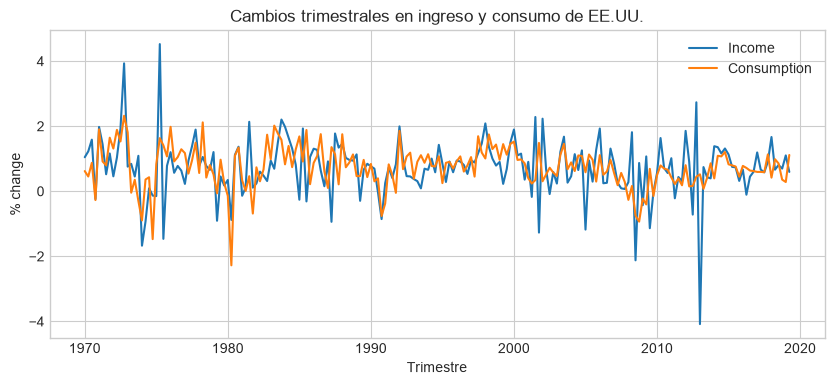

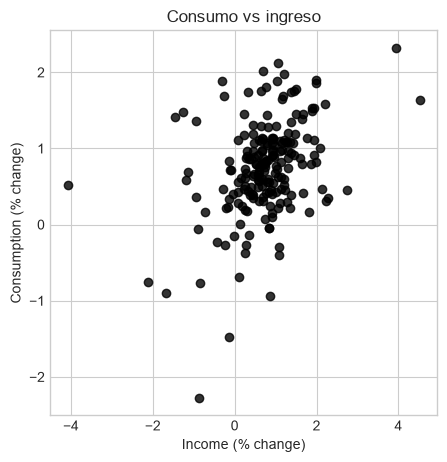

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(us_change['ds'], us_change['Income'], label='Income', color='tab:blue')
ax.plot(us_change['ds'], us_change['y'], label='Consumption', color='tab:orange')
ax.set_title('Cambios trimestrales en ingreso y consumo de EE.UU.')
ax.set_xlabel('Trimestre')
ax.set_ylabel('% change')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(us_change['Income'], us_change['y'], color='black', alpha=0.8)
ax.set_title('Consumo vs ingreso')
ax.set_xlabel('Income (% change)')
ax.set_ylabel('Consumption (% change)')
plt.show()

Residuals:
       Min        1Q    Median        3Q       Max
 -2.582358 -0.277767  0.018621  0.323295  1.422291

Coefficients:
             Estimate  Std. Error   t value      Pr(>|t|)     
(Intercept)  0.544542    0.054028  10.07881  0.000000e+00  ***
Income       0.271833    0.046729   5.81728  2.402170e-08  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.591 on 196 degrees of freedom 
Multiple R-squared: 0.147,    Adjusted R-squared: 0.143 
F-statistic: 33.8 on 1 and 196 DF, p-value: 2.4e-08


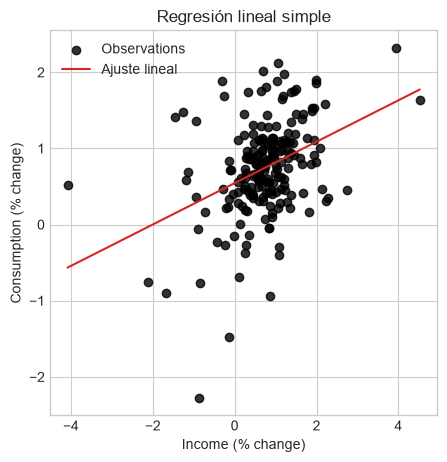

In [8]:
X_simple = us_change[['Income']]
y_simple = us_change['y']
simple_model, simple_fitted, simple_resid = fit_linear_regression(X_simple, y_simple)

regression_summary(simple_model, X_simple, y_simple, ['Income'])

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(us_change['Income'], us_change['y'], color='black', alpha=0.8, label='Observations')
x_line = np.linspace(us_change['Income'].min(), us_change['Income'].max(), 200)
pred_line = simple_model.predict(pd.DataFrame({'Income': x_line}))
ax.plot(x_line, pred_line, color='tab:red', label='Ajuste lineal')
ax.set_title('Regresión lineal simple')
ax.set_xlabel('Income (% change)')
ax.set_ylabel('Consumption (% change)')
ax.legend()
plt.show()

### Interpretación del modelo simple

El coeficiente de `Income` mide el cambio promedio esperado en el consumo cuando el ingreso cambia una unidad, manteniendo todo lo demás fijo.

En un modelo simple, esto todavía es una descripción parcial. El capítulo muestra que agregar más predictores puede mejorar mucho la capacidad explicativa del modelo.

### Graficamos los datos ajustados

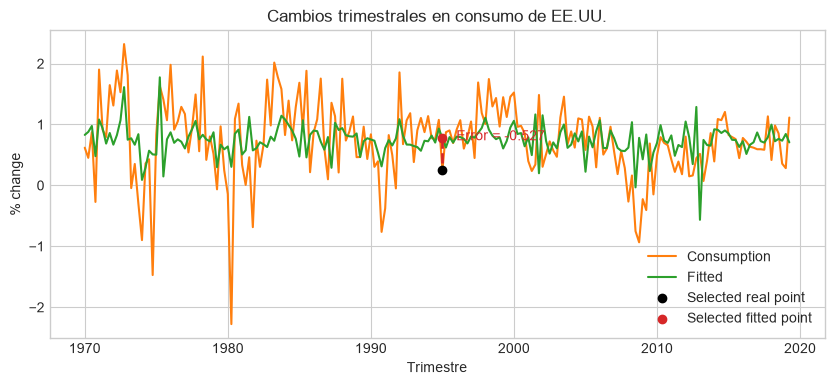

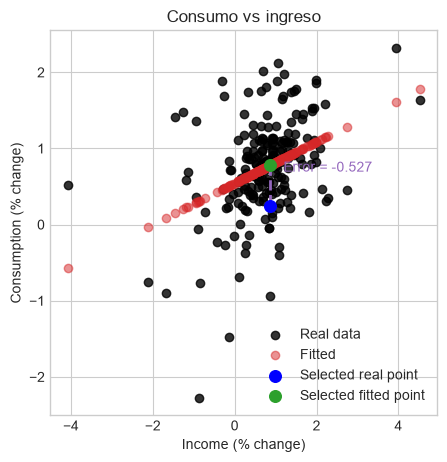

Point index: 100
Real value:   0.2486
Fitted value: 0.7759
Error:        -0.5274
Abs error:    0.5274


In [9]:
point_idx = 100  # change this index to inspect another point

x_date = us_change.loc[point_idx, 'ds']
x_income = us_change.loc[point_idx, 'Income']
y_real = us_change.loc[point_idx, 'y']
y_fit = simple_fitted.loc[point_idx]
error = y_real - y_fit

# Plot 1: time series + selected point error
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(us_change['ds'], us_change['y'], label='Consumption', color='tab:orange')
ax.plot(us_change['ds'], simple_fitted, label='Fitted', color='tab:green')

ax.scatter(x_date, y_real, color='black', zorder=5, label='Selected real point')
ax.scatter(x_date, y_fit, color='tab:red', zorder=5, label='Selected fitted point')
ax.vlines(x_date, y_fit, y_real, color='tab:red', linestyle='--', linewidth=2)
ax.annotate(f'Error = {error:.3f}',
            xy=(x_date, (y_real + y_fit) / 2),
            xytext=(10, 10),
            textcoords='offset points',
            color='tab:red')

ax.set_title('Cambios trimestrales en consumo de EE.UU.')
ax.set_xlabel('Trimestre')
ax.set_ylabel('% change')
ax.legend()
plt.show()

# Plot 2: scatter Income vs Consumption + selected point error
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(us_change['Income'], us_change['y'], color='black', alpha=0.8, label='Real data')
ax.scatter(us_change['Income'], simple_fitted, color='tab:red', alpha=0.5, label='Fitted')

ax.scatter(x_income, y_real, color='blue', s=70, zorder=6, label='Selected real point')
ax.scatter(x_income, y_fit, color='tab:green', s=70, zorder=6, label='Selected fitted point')
ax.vlines(x_income, y_fit, y_real, color='tab:purple', linestyle='--', linewidth=2)
ax.annotate(f'Error = {error:.3f}',
            xy=(x_income, (y_real + y_fit) / 2),
            xytext=(10, 10),
            textcoords='offset points',
            color='tab:purple')

ax.set_title('Consumo vs ingreso')
ax.set_xlabel('Income (% change)')
ax.set_ylabel('Consumption (% change)')
ax.legend()
plt.show()

print(f'Point index: {point_idx}')
print(f'Real value:   {y_real:.4f}')
print(f'Fitted value: {y_fit:.4f}')
print(f'Error:        {error:.4f}')
print(f'Abs error:    {abs(error):.4f}')


---

## PASO 4: Regresión múltiple (7.1 y 7.2)

El modelo múltiple extiende la idea anterior:

$$y_t = \beta_0 + \beta_1 x_{1,t} + \beta_2 x_{2,t} + \dots + \beta_k x_{k,t} + \epsilon_t$$

La clave es que cada coeficiente se interpreta como un **efecto marginal**: el efecto del predictor correspondiente, manteniendo los demás constantes.

### Inspección de los datos

y es la variable dependiente o explicada  

X es el vector de variables independientes o regresores  

In [10]:
X_multi = us_change[['Income', 'Production', 'Savings', 'Unemployment']]
y_multi = us_change[['y']]

display(X_multi.head())
display(y_multi.head())

,Income,Production,Savings,Unemployment
0,1.044801,-2.452486,5.299014,0.9
1,1.225647,-0.551459,7.789894,0.5
2,1.585154,-0.358652,7.403984,0.5
3,-0.239545,-2.185691,1.169898,0.7
4,1.975925,1.909764,3.535667,-0.1


,y
0,0.618566
1,0.451984
2,0.872872
3,-0.271848
4,1.901345


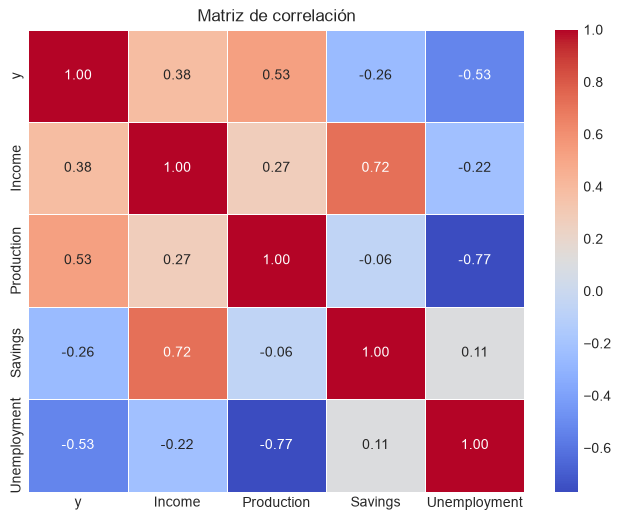

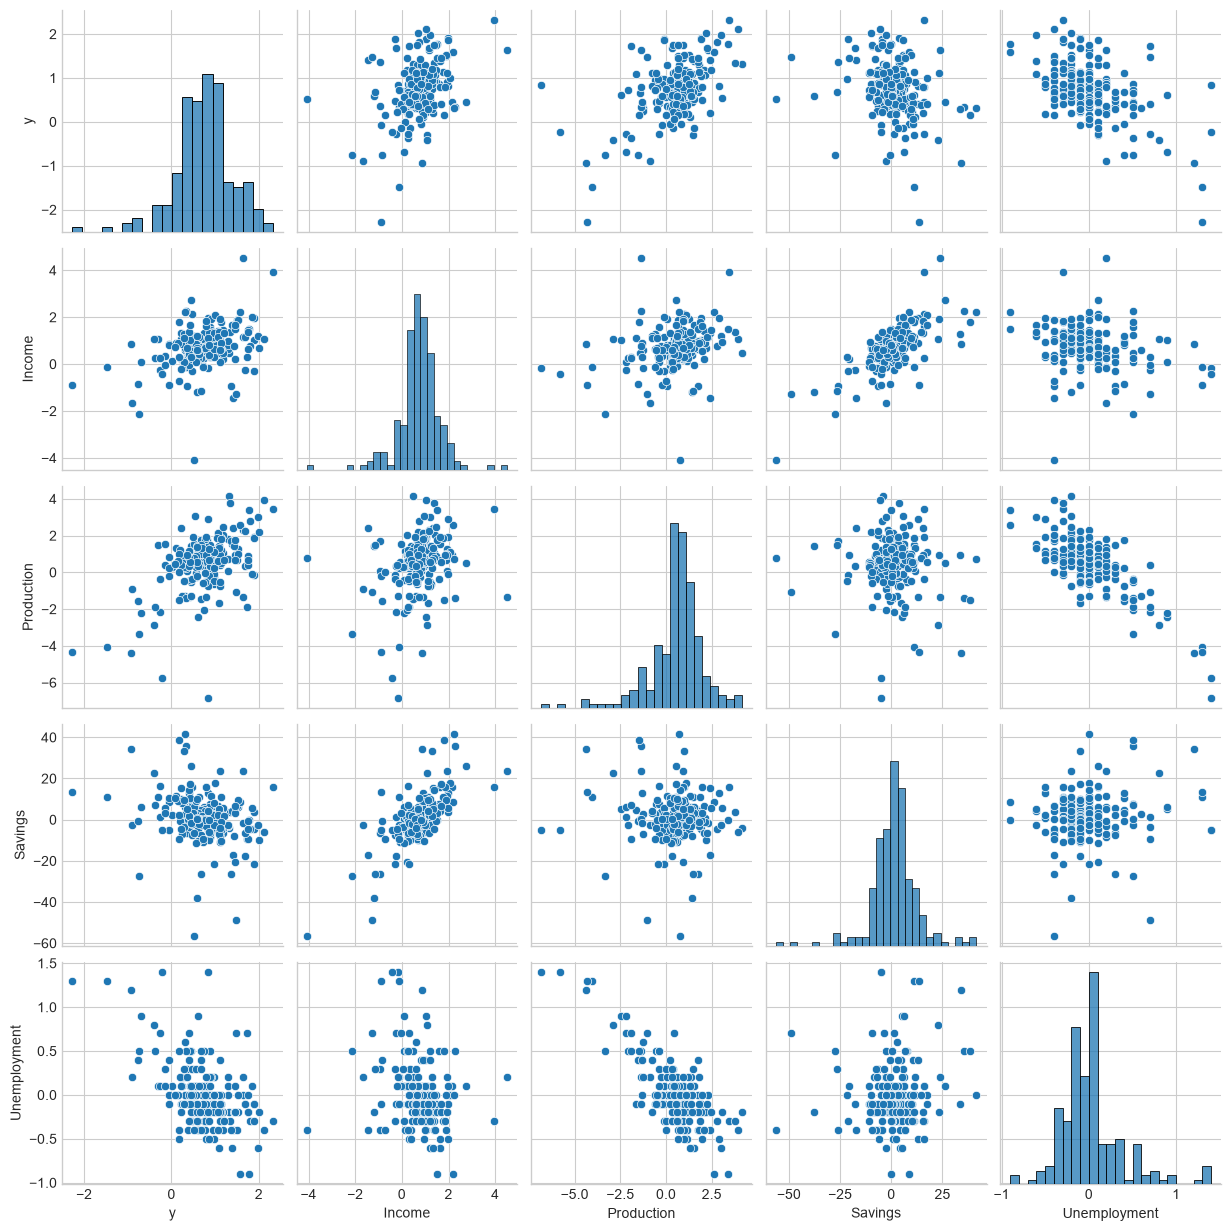

In [11]:
# Matriz de correlación
corr_matrix = us_change[['y', 'Income', 'Production', 'Savings', 'Unemployment']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlación')

# pairplot
sns.pairplot(us_change[['y', 'Income', 'Production', 'Savings', 'Unemployment']])



In [12]:


X_multi = us_change[['Income', 'Production', 'Savings', 'Unemployment']]
y_multi = us_change['y']
multi_model, multi_fitted, multi_resid = fit_linear_regression(X_multi, y_multi)

regression_summary(multi_model, X_multi, y_multi, X_multi.columns.tolist())


Residuals:
      Min        1Q    Median        3Q       Max
 -0.90555 -0.158215 -0.036078  0.136184  1.154712

Coefficients:
              Estimate  Std. Error    t value      Pr(>|t|)     
(Intercept)   0.253105    0.034470   7.342673  5.712986e-12  ***
Income        0.740583    0.040115  18.461493  0.000000e+00  ***
Production    0.047173    0.023142   2.038397  4.287439e-02    *
Savings      -0.052890    0.002924 -18.087537  0.000000e+00  ***
Unemployment -0.174685    0.095511  -1.828959  6.894900e-02    .
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.310 on 193 degrees of freedom 
Multiple R-squared: 0.768,    Adjusted R-squared: 0.763 
F-statistic: 160.0 on 4 and 193 DF, p-value: 1.11e-16


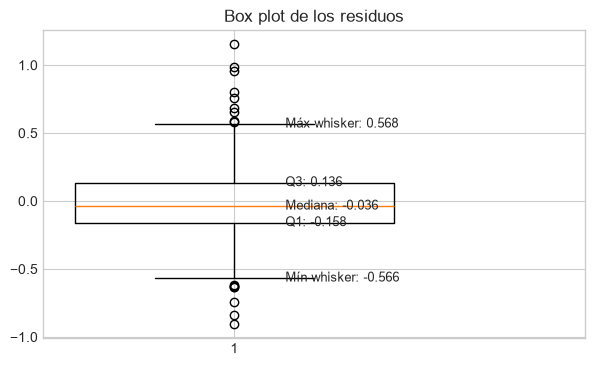

In [13]:

# box plot de los residuos con anotaciones de los valores
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(multi_resid, widths=0.5)
ax.set_title('Box plot de los residuos')

# Estadísticos de la caja
q1 = multi_resid.quantile(0.25)
med = multi_resid.quantile(0.50)
q3 = multi_resid.quantile(0.75)
iqr = q3 - q1
lower_whisker = multi_resid[multi_resid >= (q1 - 1.5 * iqr)].min()
upper_whisker = multi_resid[multi_resid <= (q3 + 1.5 * iqr)].max()

# Anotaciones
x_text = 1.08
ax.text(x_text, upper_whisker, f'Máx whisker: {upper_whisker:.3f}', va='center', fontsize=9)
ax.text(x_text, q3,            f'Q3: {q3:.3f}', va='center', fontsize=9)
ax.text(x_text, med,           f'Mediana: {med:.3f}', va='center', fontsize=9)
ax.text(x_text, q1,            f'Q1: {q1:.3f}', va='center', fontsize=9)
ax.text(x_text, lower_whisker, f'Mín whisker: {lower_whisker:.3f}', va='center', fontsize=9)

# Espacio para que se vea el texto
ax.set_xlim(0.7, 1.55)

plt.show()



### ¿Qué debemos mirar en el resumen?

- El signo de cada coeficiente.
- El tamaño relativo de los coeficientes.
- El $R^2$ y el $R^2$ ajustado.
- Los errores estándar y los valores-p, con cuidado: en pronóstico nos interesan más para entender el modelo que para hacer inferencia causal.

 se calculan e interpretan los principales indicadores del resumen:

$$
\hat{y}_t=\hat{\beta}_0+\hat{\beta}_1x_{1,t}+\cdots+\hat{\beta}_kx_{k,t}
$$

- **Estimate**: son los coeficientes estimados $\hat{\beta}_j$.  
    - Signo $+$: al aumentar $x_j$, aumenta $\hat{y}$.  
    - Signo $-$: al aumentar $x_j$, disminuye $\hat{y}$.

- **Residuals**: $e_t = y_t-\hat{y}_t$.  
    Resumen (Min, 1Q, Median, 3Q, Max) para ver sesgo y dispersión.

- **Residual standard error (RSE)**:
$$
\hat{\sigma}=\sqrt{\frac{\sum_{t=1}^n e_t^2}{n-k-1}}
$$
    Mide el tamaño típico del error (en unidades de $y$).

- **Std. Error** de cada coeficiente:
$$
SE(\hat{\beta}_j)=\sqrt{\widehat{\mathrm{Var}}(\hat{\beta}_j)}
$$

- **t value**:
$$
t_j=\frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}
$$

- **Pr(>|t|)** (valor-p): probabilidad de observar un $|t_j|$ así de extremo bajo $H_0:\beta_j=0$.  
    Menor valor-p $\Rightarrow$ mayor evidencia de que el predictor aporta información lineal.

- **$R^2$**:
$$
R^2=1-\frac{\sum e_t^2}{\sum (y_t-\bar y)^2}
$$
    Proporción de variabilidad explicada por el modelo.

- **$R^2$ ajustado**:
$$
R^2_{adj}=1-(1-R^2)\frac{n-1}{n-k-1}
$$
    Penaliza por cantidad de predictores.

- **F-statistic**: contrasta $H_0:\beta_1=\cdots=\beta_k=0$.  
    F alto y valor-p bajo $\Rightarrow$ el modelo completo mejora frente al intercepto solo.

### Graficamos los valores ajustados



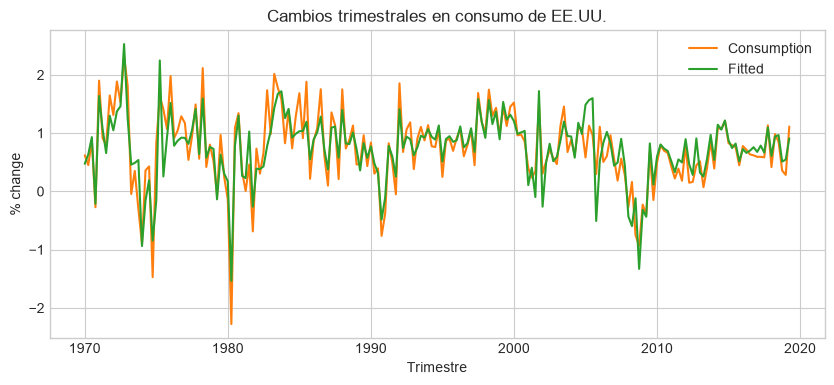

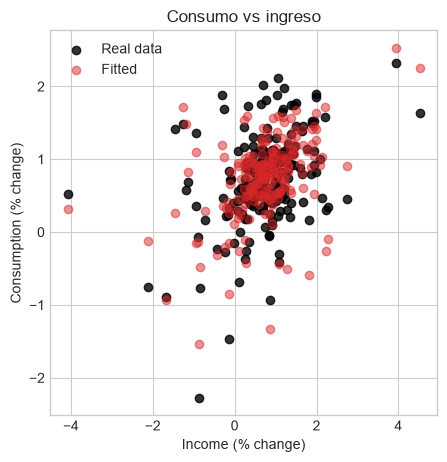

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(us_change['ds'], us_change['y'], label='Consumption', color='tab:orange')
ax.plot(us_change['ds'], multi_fitted, label='Fitted', color='tab:green')
ax.set_title('Cambios trimestrales en consumo de EE.UU.')
ax.set_xlabel('Trimestre')
ax.set_ylabel('% change')
ax.legend()
plt.show()


fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(us_change['Income'], us_change['y'], color='black', alpha=0.8, label='Real data')
ax.scatter(us_change['Income'], multi_fitted, color='tab:red', alpha=0.5, label='Fitted')
ax.set_title('Consumo vs ingreso')
ax.set_xlabel('Income (% change)')
ax.set_ylabel('Consumption (% change)')
ax.legend()
plt.show()

---

## PASO 5: Evaluar el ajuste y los residuos (7.3)

Un buen modelo de regresión para series temporales no solo debe ajustar bien, sino también dejar residuos que se parezcan a ruido blanco.

Eso significa, en términos prácticos:

1. media cercana a cero,
2. sin autocorrelación importante,
3. sin patrones claros contra predictores o valores ajustados,
4. con varianza razonablemente constante.

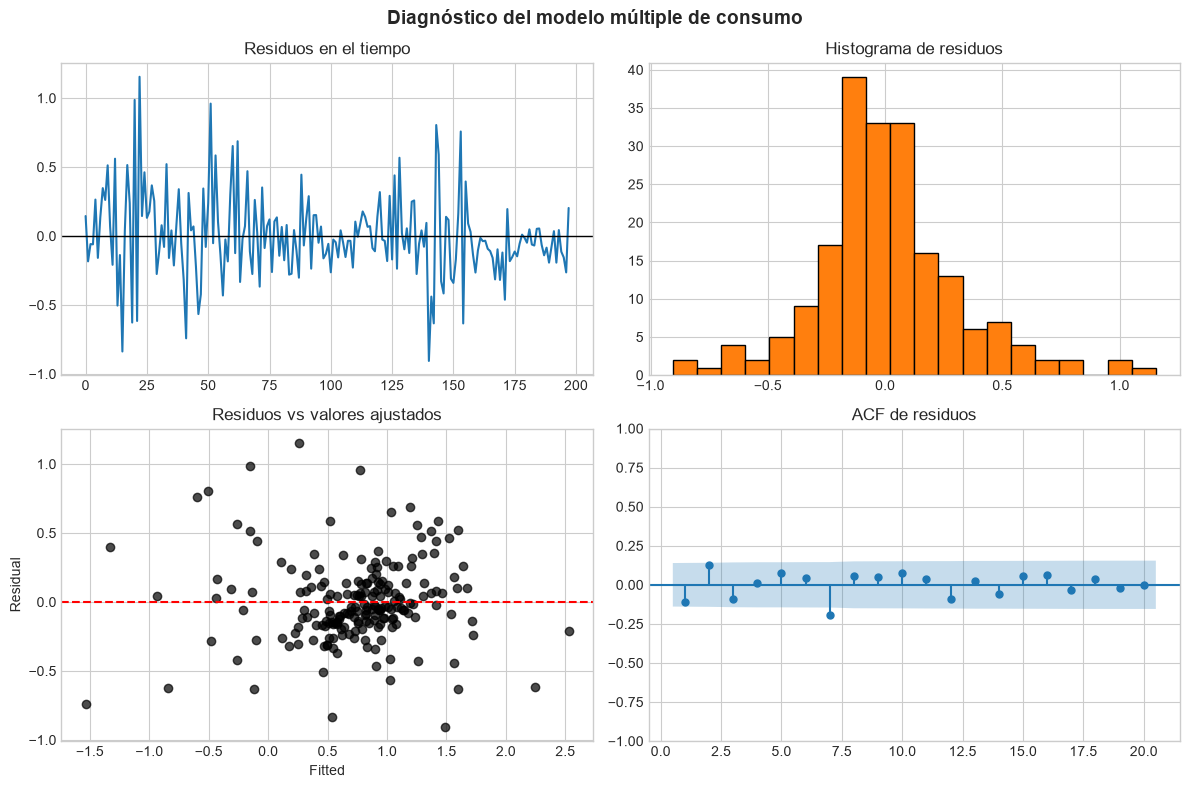

,lb_stat,lb_pvalue
10,18.865322,0.042007


In [15]:
plot_regression_diagnostics(y_multi, multi_fitted, title='Diagnóstico del modelo múltiple de consumo')

lb = acorr_ljungbox(multi_resid, lags=[10], return_df=True)
display(lb)

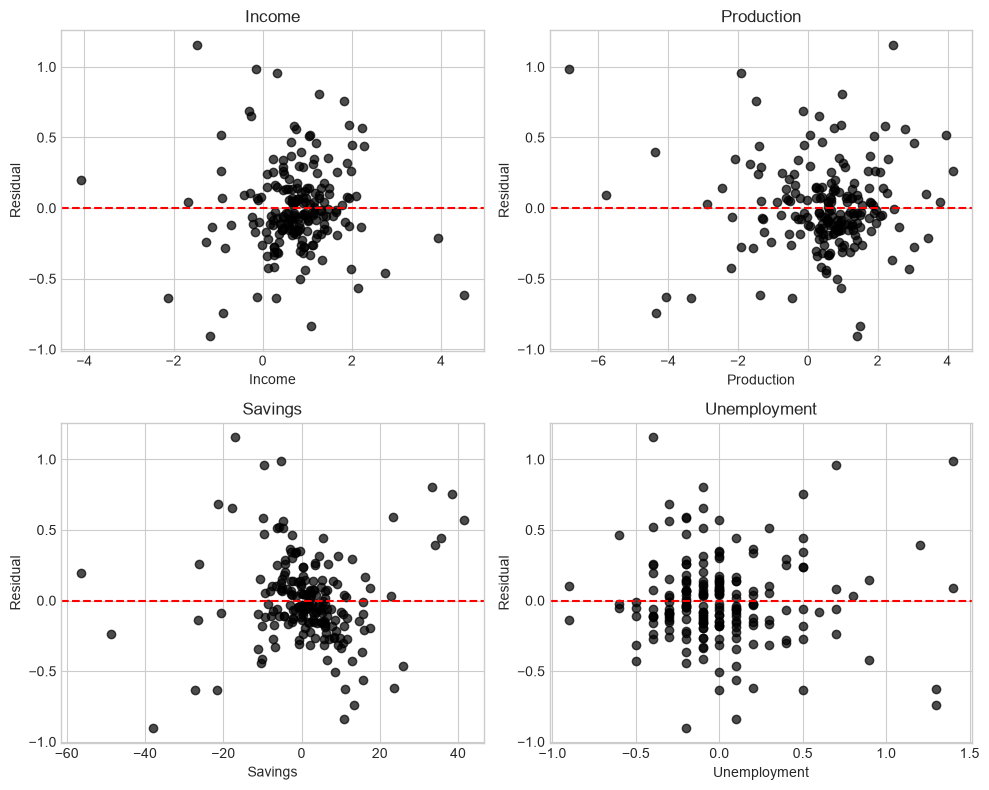

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
cols = ['Income', 'Production', 'Savings', 'Unemployment']
for ax, col in zip(axes.ravel(), cols):
    ax.scatter(us_change[col], multi_resid, color='black', alpha=0.7)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Residual')
plt.tight_layout()
plt.show()

### Lectura de los diagnósticos

Si los residuos muestran estructura, el modelo está dejando información sin explotar. En regresión para series temporales esto suele ocurrir con facilidad, porque el orden temporal introduce dependencia entre observaciones.


---

## PASO 6: Predictores útiles (7.4)

El capítulo destaca varios tipos de predictores especialmente importantes en series temporales:

- **Tendencia**: un índice temporal.
- **Dummy variables**: indicadores 0/1 para categorías o eventos.
- **Dummies estacionales**: capturan el patrón de estaciones o meses.
- **Variables de intervención**: shocks puntuales, cambios de nivel o cambios de pendiente.
- **Fourier**: aproximación flexible para estacionalidad periódica.

Vamos a ilustrar tendencia, dummies trimestrales y Fourier con la serie de cerveza.

In [17]:
beer = aus_production.loc[(aus_production['unique_id'] == 'Beer') & (aus_production['ds'] >= '1992')].copy()
beer = beer.sort_values('ds').reset_index(drop=True)
beer['trend'] = np.arange(1, len(beer) + 1)
beer['quarter'] = beer['ds'].dt.quarter.astype('category')

quarter_dummies = pd.get_dummies(beer['quarter'], prefix='Quarter', drop_first=True)
X_beer = pd.concat([beer[['trend']], quarter_dummies], axis=1)
y_beer = beer['y']

display(X_beer.head())
display(y_beer.head())

,trend,Quarter_2,Quarter_3,Quarter_4
0,1,False,False,False
1,2,True,False,False
2,3,False,True,False
3,4,False,False,True
4,5,False,False,False


0    443.0
1    410.0
2    420.0
3    532.0
4    433.0
Name: y, dtype: float64

Residuals:
        Min        1Q  Median        3Q        Max
 -42.902916 -7.599455 -0.4594  7.990813  21.789474

Coefficients:
               Estimate  Std. Error     t value      Pr(>|t|)     
(Intercept)  441.800439    3.733531  118.333149  0.000000e+00  ***
trend         -0.340268    0.066575   -5.111067  2.729654e-06  ***
Quarter_2    -34.659732    3.968323   -8.734101  9.103829e-13  ***
Quarter_3    -17.821637    4.022495   -4.430494  3.449675e-05  ***
Quarter_4     72.796408    4.023046   18.094850  0.000000e+00  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 12.229 on 69 degrees of freedom 
Multiple R-squared: 0.924,    Adjusted R-squared: 0.920 
F-statistic: 210.7 on 4 and 69 DF, p-value: 1.11e-16


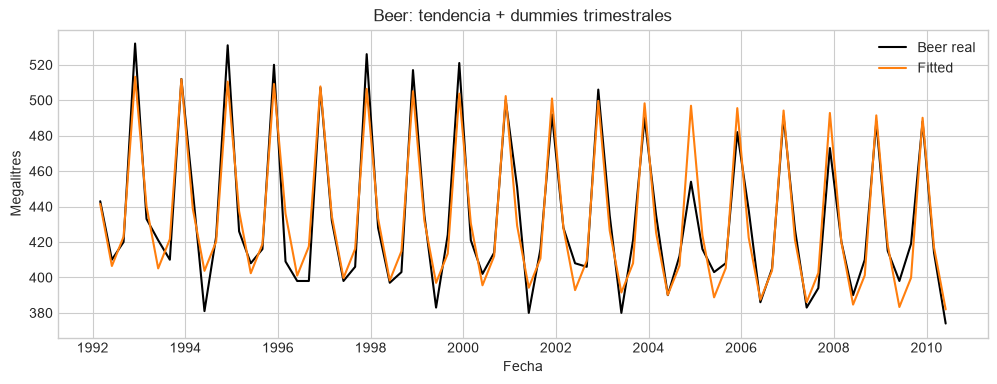

In [18]:

beer_model, beer_fitted, beer_resid = fit_linear_regression(X_beer, y_beer)

regression_summary(beer_model, X_beer, y_beer, X_beer.columns.tolist())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(beer['ds'], beer['y'], color='black', label='Beer real')
ax.plot(beer['ds'], beer_fitted, color='tab:orange', label='Fitted')
ax.set_title('Beer: tendencia + dummies trimestrales')
ax.set_xlabel('Fecha')
ax.set_ylabel('Megalitres')
ax.legend()
plt.show()

In [19]:
beer_fourier = prepare_fourier(beer, period=4, order=2)
beer_fourier = beer_fourier.drop(columns=['sin2'])
X_beer_fourier = beer_fourier[['trend', 'sin1', 'cos1', 'cos2']]
y_beer_fourier = beer_fourier['y']
display(X_beer_fourier.head())
display(y_beer_fourier.head())

,trend,sin1,cos1,cos2
0,1,1.000000e+00,6.123234e-17,-1.0
1,2,1.224647e-16,-1.000000e+00,1.0
2,3,-1.000000e+00,-1.836970e-16,-1.0
3,4,-2.449294e-16,1.000000e+00,1.0
4,5,1.000000e+00,3.061617e-16,-1.0


0    443.0
1    410.0
2    420.0
3    532.0
4    433.0
Name: y, dtype: float64

Residuals:
        Min        1Q  Median        3Q        Max
 -42.902916 -7.599455 -0.4594  7.990813  21.789474

Coefficients:
               Estimate  Std. Error     t value      Pr(>|t|)     
(Intercept)  446.879198    2.873209  155.533121  0.000000e+00  ***
trend         -0.340268    0.066575   -5.111067  2.729654e-06  ***
sin1           8.910819    2.011247    4.430494  3.449675e-05  ***
cos1          53.728070    2.011247   26.713805  0.000000e+00  ***
cos2          13.989578    1.422556    9.834113  9.325873e-15  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 12.229 on 69 degrees of freedom 
Multiple R-squared: 0.924,    Adjusted R-squared: 0.920 
F-statistic: 210.7 on 4 and 69 DF, p-value: 1.11e-16


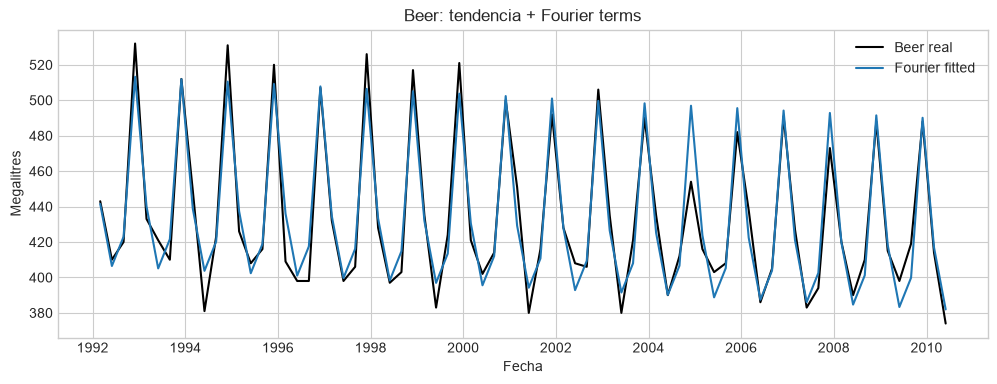

In [20]:


beer_fourier_model, beer_fourier_fitted, beer_fourier_resid = fit_linear_regression(X_beer_fourier, y_beer_fourier)

regression_summary(beer_fourier_model, X_beer_fourier, y_beer_fourier, X_beer_fourier.columns.tolist())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(beer_fourier['ds'], beer_fourier['y'], color='black', label='Beer real')
ax.plot(beer_fourier['ds'], beer_fourier_fitted, color='tab:blue', label='Fourier fitted')
ax.set_title('Beer: tendencia + Fourier terms')
ax.set_xlabel('Fecha')
ax.set_ylabel('Megalitres')
ax.legend()
plt.show()

### Qué nos enseñan estos predictores

- La tendencia capta cambios de largo plazo.
- Las dummies trimestrales capturan niveles distintos por estación.
- Fourier permite una forma más suave y compacta de representar estacionalidad.

En la práctica, si el período estacional es corto, las dummies suelen ser suficientes; si el período es largo, Fourier puede ser más eficiente.

---

## PASO 7: Selección de predictores (7.5)

El capítulo compara varios criterios para elegir predictores:

- $R^2$ ajustado
- CV (cross-validation)
- AIC
- AICc
- BIC

La idea general es simple: buscamos un buen equilibrio entre ajuste y parsimonia. Un modelo más grande no es mejor solo por tener más variables.

### Explicación de los criterios de selección

Cada criterio intenta balancear el ajuste del modelo con su complejidad:

**$R^2$ ajustado:**
$$R^2_{adj} = 1 - (1 - R^2) \frac{n-1}{n-k-1}$$

Penaliza por cantidad de predictores $k$. Valores más altos son mejores.

**CV (Cross-Validation):**
$$CV = \frac{1}{n}\sum_{i=1}^{n} \left(\frac{e_i}{1-h_{ii}}\right)^2$$

Mide el error de predicción leave-one-out. Valores más bajos son mejores.

**AIC (Akaike Information Criterion):**
$$AIC = n \log\left(\frac{RSS}{n}\right) + 2(k+2)$$

Balance entre ajuste y parsimonia. Valores más bajos son mejores.

**AICc (AIC corregido para muestras pequeñas):**
$$AICc = AIC + \frac{2(k+2)(k+3)}{n-k-3}$$

Versión mejorada de AIC para muestras finitas. Valores más bajos son mejores.

**BIC (Bayesian Information Criterion):**
$$BIC = n \log\left(\frac{RSS}{n}\right) + (k+2)\log(n)$$

Penalización más fuerte por complejidad que AIC. Valores más bajos son mejores.

In [23]:
def model_selection_table(data, response='y', predictors=None):
    if predictors is None:
        predictors = ['Income', 'Production', 'Savings', 'Unemployment']

    y = data[response].to_numpy(dtype=float)
    rows = []
    for r in range(len(predictors) + 1):
        for subset in combinations(predictors, r):
            if subset:
                X = data[list(subset)].to_numpy(dtype=float)
                X_design = np.column_stack([np.ones(len(data)), X])
                model = LinearRegression().fit(X, y)
                fitted = model.predict(X)
            else:
                X_design = np.ones((len(data), 1), dtype=float)
                fitted = np.repeat(y.mean(), len(y))
                model = None

            resid = y - fitted
            n = len(y)
            p = len(subset)
            dof = n - p - 1
            rss = np.sum(resid ** 2)
            tss = np.sum((y - y.mean()) ** 2)
            r2 = 1 - rss / tss if tss > 0 else np.nan
            adj_r2 = 1 - (1 - r2) * (n - 1) / dof if dof > 0 else np.nan
            hat = X_design @ np.linalg.inv(X_design.T @ X_design) @ X_design.T
            hdiag = np.diag(hat)
            cv = np.mean((resid / (1 - hdiag)) ** 2)
            aic = n * np.log(rss / n) + 2 * (p + 2)
            aicc = aic + (2 * (p + 2) * (p + 3)) / max(n - p - 3, 1)
            bic = n * np.log(rss / n) + (p + 2) * np.log(n)
            rows.append({
                'predictors': ', '.join(subset) if subset else '(Intercept only)',
                'r2_adj': adj_r2,
                'cv': cv,
                'aic': aic,
                'aicc': aicc,
                'bic': bic,
            })
    return pd.DataFrame(rows).sort_values('aicc')

selection = model_selection_table(us_change)
display(selection.head(10))

print('Mejores modelos según AICc:')
display(selection.head(335))

,predictors,r2_adj,cv,aic,aicc,bic
15,"Income, Production, Savings, Unemployment",0.763481,0.103897,-456.579861,-456.140070,-436.850258
11,"Income, Production, Savings",0.760621,0.104964,-455.177509,-454.865009,-438.736174
13,"Income, Savings, Unemployment",0.759634,0.104219,-454.362393,-454.049893,-437.921058
6,"Income, Savings",0.734586,0.114440,-435.717097,-435.509843,-422.564029
12,"Income, Production, Unemployment",0.365836,0.270664,-262.273881,-261.961381,-245.832545
14,"Production, Savings, Unemployment",0.349173,0.278767,-257.138394,-256.825894,-240.697059
7,"Income, Unemployment",0.344985,0.276202,-256.850342,-256.643088,-243.697274
5,"Income, Production",0.336027,0.281843,-254.160767,-253.953514,-241.007699
8,"Production, Savings",0.324248,0.287049,-250.679132,-250.471878,-237.526064
10,"Savings, Unemployment",0.311195,0.291062,-246.891077,-246.683823,-233.738009


Mejores modelos según AICc:


,predictors,r2_adj,cv,aic,aicc,bic
15,"Income, Production, Savings, Unemployment",0.763481,0.103897,-456.579861,-456.140070,-436.850258
11,"Income, Production, Savings",0.760621,0.104964,-455.177509,-454.865009,-438.736174
13,"Income, Savings, Unemployment",0.759634,0.104219,-454.362393,-454.049893,-437.921058
6,"Income, Savings",0.734586,0.114440,-435.717097,-435.509843,-422.564029
12,"Income, Production, Unemployment",0.365836,0.270664,-262.273881,-261.961381,-245.832545
14,"Production, Savings, Unemployment",0.349173,0.278767,-257.138394,-256.825894,-240.697059
7,"Income, Unemployment",0.344985,0.276202,-256.850342,-256.643088,-243.697274
5,"Income, Production",0.336027,0.281843,-254.160767,-253.953514,-241.007699
8,"Production, Savings",0.324248,0.287049,-250.679132,-250.471878,-237.526064
10,"Savings, Unemployment",0.311195,0.291062,-246.891077,-246.683823,-233.738009


### Cómo leer la tabla

- `r2_adj` más alto es mejor.
- `cv`, `aic`, `aicc` y `bic` más bajos son mejores.
- En pronóstico nos interesa que el modelo generalice, no solo que explique el entrenamiento.

La selección de predictores es una decisión de equilibrio: demasiadas variables pueden sobreajustar, y muy pocas pueden dejar fuera información útil.

---

## PASO 8: Pronóstico con regresión (7.6)

En regresión para series temporales distinguimos dos ideas:

- **Ex-post**: usamos valores futuros conocidos de los predictores.
- **Ex-ante**: solo usamos información que realmente estaría disponible al momento de pronosticar.

Cuando los predictores son determinísticos o calendarios conocidos, como tendencia o estacionalidad, ambos enfoques coinciden.

Aquí pronosticamos `Beer` usando tendencia y dummies trimestrales.

Residuals:
        Min        1Q   Median        3Q        Max
 -42.646056 -7.972176 -0.07754  7.607453  21.554144

Coefficients:
               Estimate  Std. Error     t value      Pr(>|t|)     
(Intercept)  443.277574    4.025632  110.113790  0.000000e+00  ***
trend         -0.373830    0.080561   -4.640338  1.892171e-05  ***
Quarter_2    -35.390876    4.275808   -8.277003  1.469824e-11  ***
Quarter_3    -19.941176    4.341333   -4.593330  2.237432e-05  ***
Quarter_4     72.807654    4.342080   16.767920  0.000000e+00  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 12.464 on 61 degrees of freedom 
Multiple R-squared: 0.924,    Adjusted R-squared: 0.919 
F-statistic: 184.4 on 4 and 61 DF, p-value: 1.11e-16


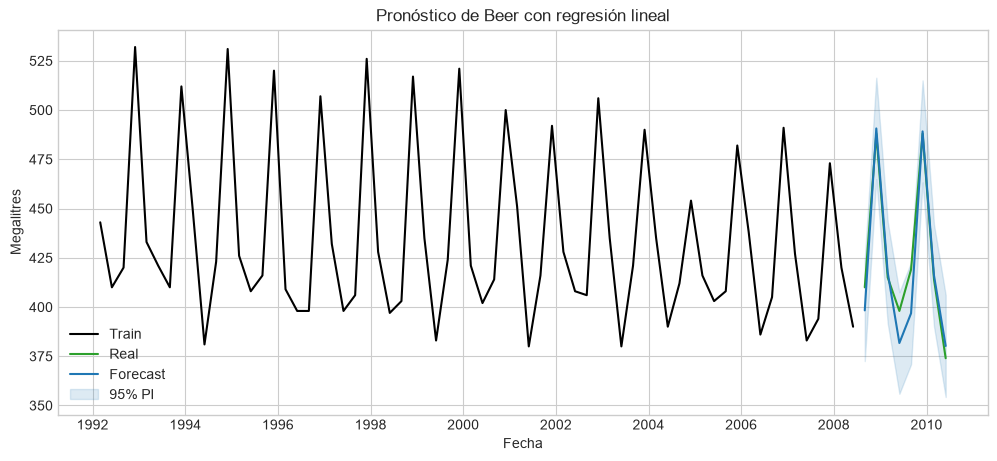

In [22]:
beer_train = beer.iloc[:-8].copy()
beer_test = beer.iloc[-8:].copy()

quarter_train = pd.get_dummies(beer_train['quarter'], prefix='Quarter', drop_first=True)
X_train = pd.concat([beer_train[['trend']], quarter_train], axis=1)
y_train = beer_train['y']
beer_reg, beer_train_fitted, beer_train_resid = fit_linear_regression(X_train, y_train)

quarter_test = pd.get_dummies(beer_test['quarter'], prefix='Quarter', drop_first=True)
X_test = pd.concat([beer_test[['trend']], quarter_test], axis=1).reindex(columns=X_train.columns, fill_value=0)

regression_summary(beer_reg, X_train, y_train, X_train.columns.tolist())

X_train_design = np.column_stack([np.ones(len(X_train)), X_train.to_numpy(dtype=float)])
X_test_design = np.column_stack([np.ones(len(X_test)), X_test.to_numpy(dtype=float)])
XtX_inv = np.linalg.inv(X_train_design.T @ X_train_design)
sigma2 = np.sum((y_train - beer_reg.predict(X_train)) ** 2) / (len(y_train) - X_train.shape[1] - 1)
pred_mean = beer_reg.predict(X_test)
pred_se = np.sqrt(sigma2 * (1 + np.einsum('ij,jk,ik->i', X_test_design, XtX_inv, X_test_design)))

beer_forecast = beer_test[['ds', 'y']].copy()
beer_forecast['mean'] = pred_mean
beer_forecast['lo95'] = pred_mean - 1.96 * pred_se
beer_forecast['hi95'] = pred_mean + 1.96 * pred_se

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(beer_train['ds'], beer_train['y'], color='black', label='Train')
ax.plot(beer_test['ds'], beer_test['y'], color='tab:green', label='Real')
ax.plot(beer_forecast['ds'], beer_forecast['mean'], color='tab:blue', label='Forecast')
ax.fill_between(beer_forecast['ds'], beer_forecast['lo95'], beer_forecast['hi95'], color='tab:blue', alpha=0.15, label='95% PI')
ax.set_title('Pronóstico de Beer con regresión lineal')
ax.set_xlabel('Fecha')
ax.set_ylabel('Megalitres')
ax.legend()
plt.show()

---

## Resumen   
### Ideas principales

1. La regresión para series temporales es una forma muy flexible de pronóstico.
2. Los predictores pueden ser numéricos, categóricos, estacionales o construidos por el analista.
3. Los residuos deben analizarse siempre: una regresión que deja estructura sin explicar suele poder mejorar.
4. Seleccionar predictores requiere un criterio de balance entre ajuste y complejidad.



---

## Ejercicio

Repetir los pasos pero usando la biblioteca StatsForecast. Ver código del capítulo del libro.
